# 01 — Análisis Exploratorio de Datos (EDA)
## Network Anomaly Detection — NSL-KDD

**Metodología:** CRISP-DM — Fase 2: Data Understanding  
**Dataset:** NSL-KDD (KDDTrain+.txt / KDDTest+.txt)  
**Herramienta:** Apache PySpark 3.5

### Preguntas a responder
1. ¿Cuál es la dimensionalidad del dataset?
2. ¿Qué tipos de datos tienen las variables?
3. ¿Hay valores faltantes?
4. ¿Cómo se distribuyen las clases? ¿Hay desbalance?
5. ¿Existen valores atípicos o distribuciones sesgadas?
6. ¿Qué variables tienen mayor correlación con la clase objetivo?
7. **Riesgos metodológicos:** ¿Hay variables con posible data leakage?

## 0. Setup

In [1]:
import os, warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
import yaml

warnings.filterwarnings('ignore')
os.environ['JAVA_HOME'] = '/Library/Java/JavaVirtualMachines/temurin-17.jdk/Contents/Home'

from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql.types import *

# Semilla fija para reproducibilidad
SEED = 42
np.random.seed(SEED)

# Cargar configuración
with open('../configs/config.yaml') as f:
    cfg = yaml.safe_load(f)

# Iniciar SparkSession
spark = SparkSession.builder \
    .appName(cfg['spark']['app_name']) \
    .master(cfg['spark']['master']) \
    .config('spark.driver.memory', cfg['spark']['driver_memory']) \
    .config('spark.ui.showConsoleProgress', 'false') \
    .getOrCreate()

spark.sparkContext.setLogLevel('ERROR')
print(f'PySpark {spark.version} iniciado — {spark.sparkContext.defaultParallelism} cores')

26/05/10 04:08:13 WARN Utils: Your hostname, MacBook-Pro-3.local resolves to a loopback address: 127.0.0.1; using 192.168.0.51 instead (on interface en0)
26/05/10 04:08:13 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/05/10 04:08:14 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


PySpark 3.5.1 iniciado — 8 cores


## 1. Carga del Dataset

In [2]:
# Nombres de columnas NSL-KDD (41 features + label + difficulty)
COL_NAMES = [
    'duration', 'protocol_type', 'service', 'flag', 'src_bytes', 'dst_bytes',
    'land', 'wrong_fragment', 'urgent', 'hot', 'num_failed_logins', 'logged_in',
    'num_compromised', 'root_shell', 'su_attempted', 'num_root', 'num_file_creations',
    'num_shells', 'num_access_files', 'num_outbound_cmds', 'is_host_login',
    'is_guest_login', 'count', 'srv_count', 'serror_rate', 'srv_serror_rate',
    'rerror_rate', 'srv_rerror_rate', 'same_srv_rate', 'diff_srv_rate',
    'srv_diff_host_rate', 'dst_host_count', 'dst_host_srv_count',
    'dst_host_same_srv_rate', 'dst_host_diff_srv_rate', 'dst_host_same_src_port_rate',
    'dst_host_srv_diff_host_rate', 'dst_host_serror_rate', 'dst_host_srv_serror_rate',
    'dst_host_rerror_rate', 'dst_host_srv_rerror_rate',
    'attack_type', 'difficulty'
]

# Variables categóricas
CAT_COLS = ['protocol_type', 'service', 'flag']

# Mapeo de ataques → categoría
ATTACK_MAP = {
    'normal': 'Normal',
    # DoS
    'neptune':'DoS','back':'DoS','land':'DoS','pod':'DoS','smurf':'DoS',
    'teardrop':'DoS','mailbomb':'DoS','apache2':'DoS','processtable':'DoS','udpstorm':'DoS',
    # Probe
    'ipsweep':'Probe','nmap':'Probe','portsweep':'Probe','satan':'Probe',
    'mscan':'Probe','saint':'Probe',
    # R2L
    'ftp_write':'R2L','guess_passwd':'R2L','imap':'R2L','multihop':'R2L',
    'phf':'R2L','spy':'R2L','warezclient':'R2L','warezmaster':'R2L',
    'sendmail':'R2L','named':'R2L','snmpattack':'R2L','snmpgetattack':'R2L',
    'xlock':'R2L','xsnoop':'R2L','worm':'R2L',
    # U2R
    'buffer_overflow':'U2R','loadmodule':'U2R','perl':'U2R','rootkit':'U2R',
    'httptunnel':'U2R','ps':'U2R','sqlattack':'U2R','xterm':'U2R'
}

def load_nslkdd(path):
    df = spark.read.csv(path, header=False, inferSchema=True)
    # Renombrar columnas
    for i, name in enumerate(COL_NAMES):
        df = df.withColumnRenamed(f'_c{i}', name)
    # Mapear ataque → categoría
    attack_map_expr = F.create_map([F.lit(x) for kv in ATTACK_MAP.items() for x in kv])
    df = df.withColumn('attack_category',
                       F.coalesce(attack_map_expr[F.col('attack_type')],
                                  F.lit('Unknown')))
    return df

train_raw = load_nslkdd('../data/raw/KDDTrain+.txt')
test_raw  = load_nslkdd('../data/raw/KDDTest+.txt')

print(f'Train: {train_raw.count():,} registros')
print(f'Test:  {test_raw.count():,} registros')
print(f'Columnas: {len(train_raw.columns)}')

Train: 125,973 registros
Test:  22,544 registros
Columnas: 44


## 2. Inspección General

In [3]:
# Schema
train_raw.printSchema()

root
 |-- duration: integer (nullable = true)
 |-- protocol_type: string (nullable = true)
 |-- service: string (nullable = true)
 |-- flag: string (nullable = true)
 |-- src_bytes: integer (nullable = true)
 |-- dst_bytes: integer (nullable = true)
 |-- land: integer (nullable = true)
 |-- wrong_fragment: integer (nullable = true)
 |-- urgent: integer (nullable = true)
 |-- hot: integer (nullable = true)
 |-- num_failed_logins: integer (nullable = true)
 |-- logged_in: integer (nullable = true)
 |-- num_compromised: integer (nullable = true)
 |-- root_shell: integer (nullable = true)
 |-- su_attempted: integer (nullable = true)
 |-- num_root: integer (nullable = true)
 |-- num_file_creations: integer (nullable = true)
 |-- num_shells: integer (nullable = true)
 |-- num_access_files: integer (nullable = true)
 |-- num_outbound_cmds: integer (nullable = true)
 |-- is_host_login: integer (nullable = true)
 |-- is_guest_login: integer (nullable = true)
 |-- count: integer (nullable = true

In [4]:
# Primeras filas
train_raw.select(COL_NAMES[:10] + ['attack_category']).show(5, truncate=False)

+--------+-------------+--------+----+---------+---------+----+--------------+------+---+---------------+
|duration|protocol_type|service |flag|src_bytes|dst_bytes|land|wrong_fragment|urgent|hot|attack_category|
+--------+-------------+--------+----+---------+---------+----+--------------+------+---+---------------+
|0       |tcp          |ftp_data|SF  |491      |0        |0   |0             |0     |0  |Normal         |
|0       |udp          |other   |SF  |146      |0        |0   |0             |0     |0  |Normal         |
|0       |tcp          |private |S0  |0        |0        |0   |0             |0     |0  |DoS            |
|0       |tcp          |http    |SF  |232      |8153     |0   |0             |0     |0  |Normal         |
|0       |tcp          |http    |SF  |199      |420      |0   |0             |0     |0  |Normal         |
+--------+-------------+--------+----+---------+---------+----+--------------+------+---+---------------+
only showing top 5 rows



In [5]:
# Valores nulos por columna
null_counts = train_raw.select([
    F.count(F.when(F.col(c).isNull(), c)).alias(c)
    for c in COL_NAMES[:-1]
])
null_pd = null_counts.toPandas().T
null_pd.columns = ['null_count']
print('Columnas con valores nulos:')
print(null_pd[null_pd['null_count'] > 0])
print('\n✓ Sin valores nulos' if null_pd['null_count'].sum() == 0 else '⚠ Hay nulos')

Columnas con valores nulos:
Empty DataFrame
Columns: [null_count]
Index: []

✓ Sin valores nulos


## 3. Distribución de Clases

attack_category  count   pct
         Normal  67343 53.46
            DoS  45927 36.46
          Probe  11656  9.25
            R2L    995  0.79
            U2R     52  0.04


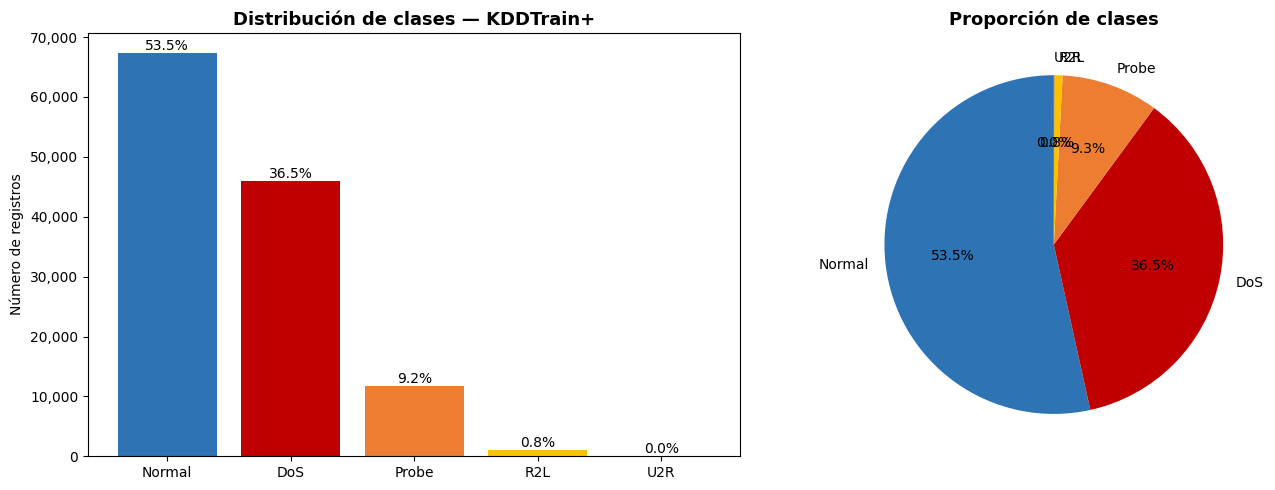

✓ Guardado: reports/01_class_distribution.png


In [6]:
# Conteo por categoría
dist = train_raw.groupBy('attack_category').count() \
                .orderBy('count', ascending=False).toPandas()
total = dist['count'].sum()
dist['pct'] = (dist['count'] / total * 100).round(2)
print(dist.to_string(index=False))

# Visualización
colors = {'Normal':'#2E74B5', 'DoS':'#C00000', 'Probe':'#ED7D31',
          'R2L':'#FFC000', 'U2R':'#7030A0', 'Unknown':'#808080'}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Barplot
ax = axes[0]
bars = ax.bar(dist['attack_category'], dist['count'],
              color=[colors.get(c, '#808080') for c in dist['attack_category']])
ax.set_title('Distribución de clases — KDDTrain+', fontsize=13, fontweight='bold')
ax.set_ylabel('Número de registros')
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
for bar, pct in zip(bars, dist['pct']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 500,
            f'{pct:.1f}%', ha='center', fontsize=10)

# Pie chart
ax2 = axes[1]
ax2.pie(dist['count'], labels=dist['attack_category'],
        colors=[colors.get(c,'#808080') for c in dist['attack_category']],
        autopct='%1.1f%%', startangle=90)
ax2.set_title('Proporción de clases', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('../reports/01_class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('✓ Guardado: reports/01_class_distribution.png')

## 4. Variables Categóricas

In [7]:
for col in CAT_COLS:
    vals = train_raw.groupBy(col).count().orderBy('count', ascending=False).toPandas()
    print(f'\n{col} ({len(vals)} valores únicos):')
    print(vals.head(10).to_string(index=False))


protocol_type (3 valores únicos):
protocol_type  count
          tcp 102689
          udp  14993
         icmp   8291

service (70 valores únicos):
 service  count
    http  40338
 private  21853
domain_u   9043
    smtp   7313
ftp_data   6860
   eco_i   4586
   other   4359
   ecr_i   3077
  telnet   2353
  finger   1767

flag (11 valores únicos):
  flag  count
    SF  74945
    S0  34851
   REJ  11233
  RSTR   2421
  RSTO   1562
    S1    365
    SH    271
    S2    127
RSTOS0    103
    S3     49


## 5. Estadísticas Descriptivas (variables numéricas clave)

In [8]:
NUM_COLS = ['duration', 'src_bytes', 'dst_bytes', 'num_failed_logins',
            'num_root', 'serror_rate', 'rerror_rate', 'same_srv_rate',
            'diff_srv_rate', 'dst_host_srv_count', 'dst_host_serror_rate']

train_raw.select(NUM_COLS).describe().show()

+-------+-----------------+-----------------+------------------+--------------------+-------------------+-------------------+-------------------+------------------+-------------------+------------------+--------------------+
|summary|         duration|        src_bytes|         dst_bytes|   num_failed_logins|           num_root|        serror_rate|        rerror_rate|     same_srv_rate|      diff_srv_rate|dst_host_srv_count|dst_host_serror_rate|
+-------+-----------------+-----------------+------------------+--------------------+-------------------+-------------------+-------------------+------------------+-------------------+------------------+--------------------+
|  count|           125973|           125973|            125973|              125973|             125973|             125973|             125973|            125973|             125973|            125973|              125973|
|   mean|287.1446500440571|45566.74300048423|19779.114421344257|0.001222484183118...|0.3021917394997

## 6. Variables Constantes y Quasi-Constantes

In [9]:
# Variables con muy baja varianza (candidatas a eliminar)
numeric_cols = [f.name for f in train_raw.schema.fields
                if isinstance(f.dataType, (IntegerType, DoubleType, LongType))
                and f.name not in ['difficulty']]

stats = train_raw.select([F.stddev(c).alias(c) for c in numeric_cols]).toPandas().T
stats.columns = ['std_dev']
quasi_const = stats[stats['std_dev'] < 0.01]
print(f'Variables quasi-constantes (std < 0.01): {len(quasi_const)}')
print(quasi_const)

Variables quasi-constantes (std < 0.01): 2
                    std_dev
num_outbound_cmds  0.000000
is_host_login      0.002817


## 7. Distribución Train vs Test

attack_category   train  test  train_pct  test_pct  diff_pct
            DoS 45927.0  7458      36.46     33.08     -3.38
         Normal 67343.0  9711      53.46     43.08    -10.38
          Probe 11656.0  2421       9.25     10.74      1.49
            R2L   995.0  2423       0.79     10.75      9.96
            U2R    52.0   200       0.04      0.89      0.85
        Unknown     0.0   331       0.00      1.47      1.47


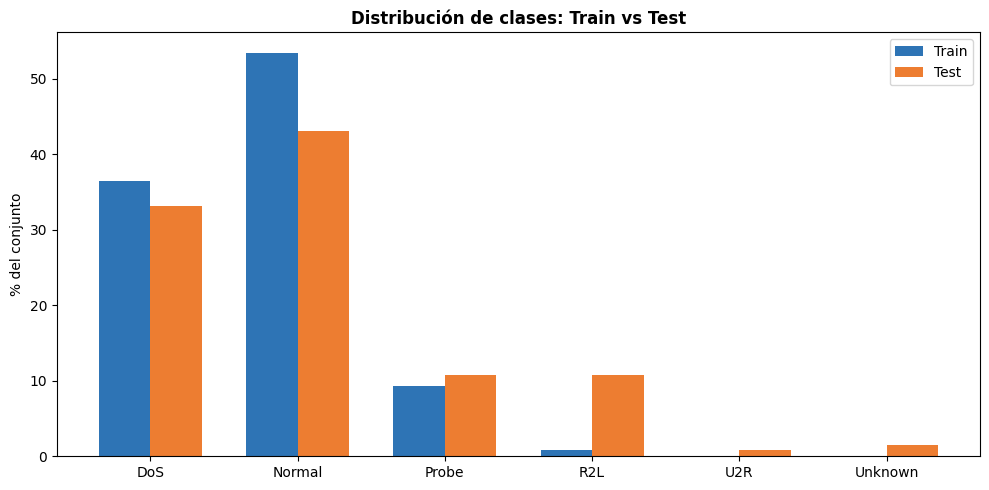

In [10]:
# Comparar distribución de clases entre train y test
dist_train = train_raw.groupBy('attack_category').count() \
                      .withColumnRenamed('count','train').toPandas()
dist_test  = test_raw.groupBy('attack_category').count() \
                     .withColumnRenamed('count','test').toPandas()

comp = dist_train.merge(dist_test, on='attack_category', how='outer').fillna(0)
comp['train_pct'] = (comp['train'] / comp['train'].sum() * 100).round(2)
comp['test_pct']  = (comp['test']  / comp['test'].sum()  * 100).round(2)
comp['diff_pct']  = (comp['test_pct'] - comp['train_pct']).round(2)
print(comp.to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 5))
x = range(len(comp))
w = 0.35
ax.bar([i - w/2 for i in x], comp['train_pct'], w, label='Train', color='#2E74B5')
ax.bar([i + w/2 for i in x], comp['test_pct'],  w, label='Test',  color='#ED7D31')
ax.set_xticks(list(x))
ax.set_xticklabels(comp['attack_category'])
ax.set_ylabel('% del conjunto')
ax.set_title('Distribución de clases: Train vs Test', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('../reports/02_train_vs_test_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Correlación con la clase objetivo

Top 15 features por correlación con la clase objetivo:
                    feature  corr_abs      corr
         dst_host_srv_count  0.624241 -0.624241
                  logged_in  0.576031 -0.576031
     dst_host_same_srv_rate  0.525829 -0.525829
              same_srv_rate  0.510871 -0.510871
     dst_host_diff_srv_rate  0.391328  0.391328
                      count  0.388358  0.388358
   dst_host_srv_serror_rate  0.384796  0.384796
       dst_host_serror_rate  0.382118  0.382118
                serror_rate  0.381646  0.381646
            srv_serror_rate  0.378669  0.378669
dst_host_same_src_port_rate  0.319096  0.319096
   dst_host_srv_rerror_rate  0.310227  0.310227
            srv_rerror_rate  0.309909  0.309909
                rerror_rate  0.308668  0.308668
       dst_host_rerror_rate  0.293805  0.293805


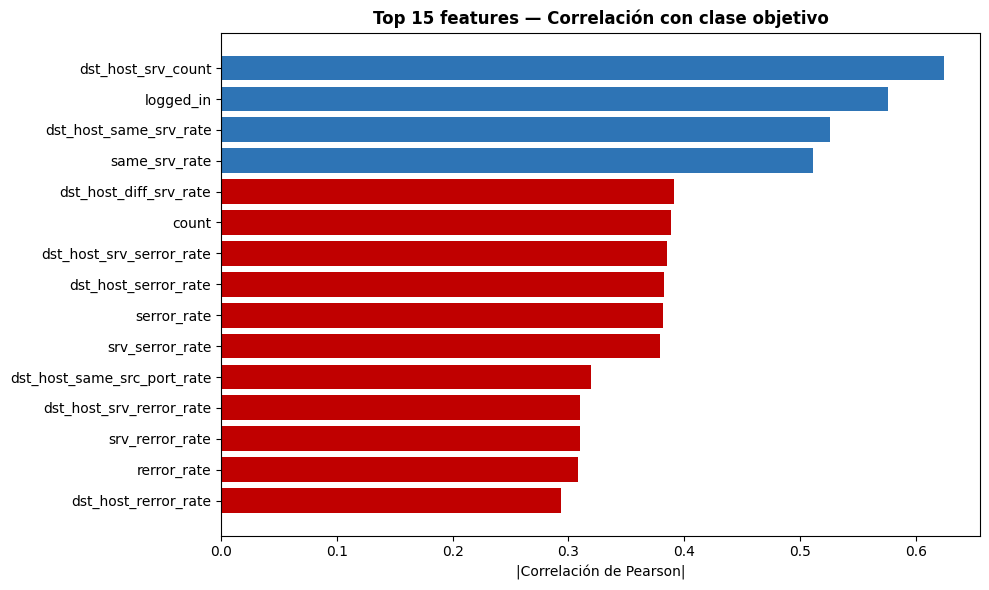

In [11]:
from pyspark.ml.feature import StringIndexer

# Indexar la clase objetivo para correlación
indexer = StringIndexer(inputCol='attack_category', outputCol='label')
train_indexed = indexer.fit(train_raw).transform(train_raw)

# Correlación de Pearson de cada numérica con el label
correlations = []
for col in numeric_cols:
    corr = train_indexed.stat.corr(col, 'label')
    correlations.append({'feature': col, 'corr_abs': abs(corr), 'corr': corr})

corr_df = pd.DataFrame(correlations).sort_values('corr_abs', ascending=False)
print('Top 15 features por correlación con la clase objetivo:')
print(corr_df.head(15).to_string(index=False))

# Visualización
top15 = corr_df.head(15)
fig, ax = plt.subplots(figsize=(10, 6))
colors_bar = ['#C00000' if c > 0 else '#2E74B5' for c in top15['corr']]
ax.barh(top15['feature'], top15['corr_abs'], color=colors_bar)
ax.set_xlabel('|Correlación de Pearson|')
ax.set_title('Top 15 features — Correlación con clase objetivo', fontweight='bold')
ax.invert_yaxis()
plt.tight_layout()
plt.savefig('../reports/03_feature_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. ⚠️ Riesgos Metodológicos Identificados

In [12]:
print("""
RIESGOS METODOLÓGICOS — NSL-KDD
=================================

1. VARIABLES DE CONTEO CON VENTANA TEMPORAL
   Variables como 'count', 'srv_count', 'dst_host_count' etc. se calculan
   sobre las últimas N conexiones. En producción esto es válido (existe
   antes de la decisión). En el dataset están pre-calculadas → OK, no es leakage.

2. VARIABLE 'difficulty'
   Columna 43 del dataset. Es una calificación asignada por expertos
   DESPUÉS de conocer la etiqueta. NO debe usarse como predictor.
   → ACCIÓN: excluir 'difficulty' de todas las features.

3. VARIABLE 'attack_type' vs 'attack_category'
   'attack_type' es el nombre específico del ataque (neptune, smurf, etc.)
   'attack_category' es el agrupamiento que usamos como label.
   → ACCIÓN: excluir 'attack_type' de los predictores.

4. DESBALANCE SEVERO EN R2L y U2R
   Estas clases tienen muy pocos ejemplos. El modelo puede ignorarlas
   y aún tener accuracy alto. Por eso usamos F1-macro y Recall por clase.
   → ACCIÓN: usar class_weight o sobremuestreo en preprocesamiento.

5. DIFERENCIA TRAIN vs TEST
   NSL-KDD Test contiene tipos de ataque no vistos en Train (especialmente
   en R2L y U2R). Esto es intencional en el benchmark para probar generalización.
   → ACCIÓN: reportar métricas separadas para ataques 'vistos' vs 'no vistos'.

6. ESCALADORES Y ENCODERS
   Todos los transformadores deben ajustarse SOLO con train.
   → ACCIÓN: garantizado con PySpark Pipeline (fit en train, transform en val/test).
""")


RIESGOS METODOLÓGICOS — NSL-KDD

1. VARIABLES DE CONTEO CON VENTANA TEMPORAL
   Variables como 'count', 'srv_count', 'dst_host_count' etc. se calculan
   sobre las últimas N conexiones. En producción esto es válido (existe
   antes de la decisión). En el dataset están pre-calculadas → OK, no es leakage.

2. VARIABLE 'difficulty'
   Columna 43 del dataset. Es una calificación asignada por expertos
   DESPUÉS de conocer la etiqueta. NO debe usarse como predictor.
   → ACCIÓN: excluir 'difficulty' de todas las features.

3. VARIABLE 'attack_type' vs 'attack_category'
   'attack_type' es el nombre específico del ataque (neptune, smurf, etc.)
   'attack_category' es el agrupamiento que usamos como label.
   → ACCIÓN: excluir 'attack_type' de los predictores.

4. DESBALANCE SEVERO EN R2L y U2R
   Estas clases tienen muy pocos ejemplos. El modelo puede ignorarlas
   y aún tener accuracy alto. Por eso usamos F1-macro y Recall por clase.
   → ACCIÓN: usar class_weight o sobremuestreo en prepro

## 10. Guardar dataset limpio

In [13]:
# Columnas a usar como features (excluir attack_type, difficulty, attack_category)
FEATURE_COLS = [c for c in COL_NAMES
                if c not in ['attack_type', 'difficulty', 'attack_category']]

# Guardar versión limpia (con label) en Parquet para el pipeline
train_clean = train_raw.select(FEATURE_COLS + ['attack_category'])
test_clean  = test_raw.select(FEATURE_COLS  + ['attack_category'])

train_clean.write.mode('overwrite').parquet('../data/processed/train_clean.parquet')
test_clean.write.mode('overwrite').parquet('../data/processed/test_clean.parquet')

print(f'✓ Train guardado: {train_clean.count():,} registros, {len(FEATURE_COLS)} features')
print(f'✓ Test  guardado: {test_clean.count():,} registros')
print(f'✓ Features finales: {FEATURE_COLS}')

✓ Train guardado: 125,973 registros, 41 features
✓ Test  guardado: 22,544 registros
✓ Features finales: ['duration', 'protocol_type', 'service', 'flag', 'src_bytes', 'dst_bytes', 'land', 'wrong_fragment', 'urgent', 'hot', 'num_failed_logins', 'logged_in', 'num_compromised', 'root_shell', 'su_attempted', 'num_root', 'num_file_creations', 'num_shells', 'num_access_files', 'num_outbound_cmds', 'is_host_login', 'is_guest_login', 'count', 'srv_count', 'serror_rate', 'srv_serror_rate', 'rerror_rate', 'srv_rerror_rate', 'same_srv_rate', 'diff_srv_rate', 'srv_diff_host_rate', 'dst_host_count', 'dst_host_srv_count', 'dst_host_same_srv_rate', 'dst_host_diff_srv_rate', 'dst_host_same_src_port_rate', 'dst_host_srv_diff_host_rate', 'dst_host_serror_rate', 'dst_host_srv_serror_rate', 'dst_host_rerror_rate', 'dst_host_srv_rerror_rate']


In [14]:
spark.stop()
print('✓ SparkSession cerrada')

✓ SparkSession cerrada
